In [ ]:
import os
import sys
sys.path.insert(0, '../')

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.formla_dataset import get_4mula_data_loaders
from src.vae import BasicVAE, VAELoss
from src.training import train_vae, extract_latent_features
from src.clustering import ClusteringPipeline
from src.evaluation import MetricsEvaluator
from src.visualization import Visualizer  # <-- THIS LINE IS CRITICAL!

device = config.DEVICE
print(f"✓ Device: {device}")


✓ Config loaded
✓ Using device: cpu
✓ Device: cpu


In [3]:
import os
parquet_file = os.path.join(config.FORMLA_DIR, '4mula_tiny.parquet')
file_size_mb = os.path.getsize(parquet_file) / (1024 * 1024)
print(f"Parquet file size: {file_size_mb:.2f} MB")


Parquet file size: 2504.35 MB


In [4]:
# TEMPORARY SOLUTION: Create synthetic test dataset
print("Creating synthetic test dataset (200 songs)...")

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SyntheticMusicDataset(Dataset):
    """Synthetic music dataset for testing"""
    
    def __init__(self, n_samples=200, mode='easy'):
        self.n_samples = n_samples
        self.mode = mode
        
        # Generate random audio features (256 dimensions)
        np.random.seed(42)
        self.audio_features = np.random.randn(n_samples, 256).astype(np.float32)
        
        # Generate random lyrics features if needed (300 dimensions)
        if mode in ['medium', 'hard']:
            self.lyrics_features = np.random.randn(n_samples, 300).astype(np.float32)
        
        # Generate random genre labels if needed
        if mode == 'hard':
            self.genre_labels = np.random.randint(0, 10, n_samples)
            self.genre_to_idx = {f'genre_{i}': i for i in range(10)}
            self.idx_to_genre = {i: f'genre_{i}' for i in range(10)}
        
        print(f"✓ Created synthetic dataset:")
        print(f"  Mode: {mode}")
        print(f"  Samples: {n_samples}")
        print(f"  Audio features: {self.audio_features.shape}")
        if mode in ['medium', 'hard']:
            print(f"  Lyrics features: {self.lyrics_features.shape}")
        if mode == 'hard':
            print(f"  Genres: {len(self.genre_to_idx)}")
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        if self.mode == 'easy':
            return torch.FloatTensor(self.audio_features[idx]), idx
        elif self.mode == 'medium':
            features = np.concatenate([self.audio_features[idx], self.lyrics_features[idx]])
            return torch.FloatTensor(features), idx
        elif self.mode == 'hard':
            features = np.concatenate([self.audio_features[idx], self.lyrics_features[idx]])
            genre = self.genre_labels[idx]
            return torch.FloatTensor(features), torch.LongTensor([genre]), idx

# Create dataset
dataset = SyntheticMusicDataset(n_samples=200, mode='easy')

# Split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

# Get input dimension
sample_features, _ = dataset[0]
input_dim = sample_features.shape[0]

print(f"\n✓ Data loaders created:")
print(f"  Train: {len(train_set)} samples")
print(f"  Test: {len(test_set)} samples")
print(f"  Input dim: {input_dim}")
print(f"  Batch size: 8")


Creating synthetic test dataset (200 songs)...
✓ Created synthetic dataset:
  Mode: easy
  Samples: 200
  Audio features: (200, 256)

✓ Data loaders created:
  Train: 160 samples
  Test: 40 samples
  Input dim: 256
  Batch size: 8


In [5]:
vae = BasicVAE(
    input_dim=input_dim,
    latent_dim=config.LATENT_DIM_EASY,
    hidden_dim=config.HIDDEN_DIM
)
criterion = VAELoss(beta=1.0)
vae = vae.to(device)

print(f"✓ VAE created")
params = sum(p.numel() for p in vae.parameters())
print(f"  Parameters: {params:,}")


✓ VAE created
  Parameters: 278,824


In [6]:
trained_vae, history = train_vae(
    vae,
    criterion,
    train_loader,
    test_loader,
    epochs=config.EPOCHS,
    lr=config.LEARNING_RATE,
    device=device,
    save_path=os.path.join(config.MODELS_DIR, 'vae_easy.pth')
)

print(f"✓ Training complete")


Epoch 10: Train=159.5648, Test=161.8613


Epoch 20: Train=159.3337, Test=161.8515


Epoch 30: Train=159.0818, Test=161.7925


Epoch 40: Train=158.8081, Test=162.0009


Epoch 50: Train=158.4536, Test=162.1135
✓ Model saved to E:\vae-music-clustering\models\vae_easy.pth
✓ Training complete


✓ Saved: E:\vae-music-clustering\results\easy_training_history.png


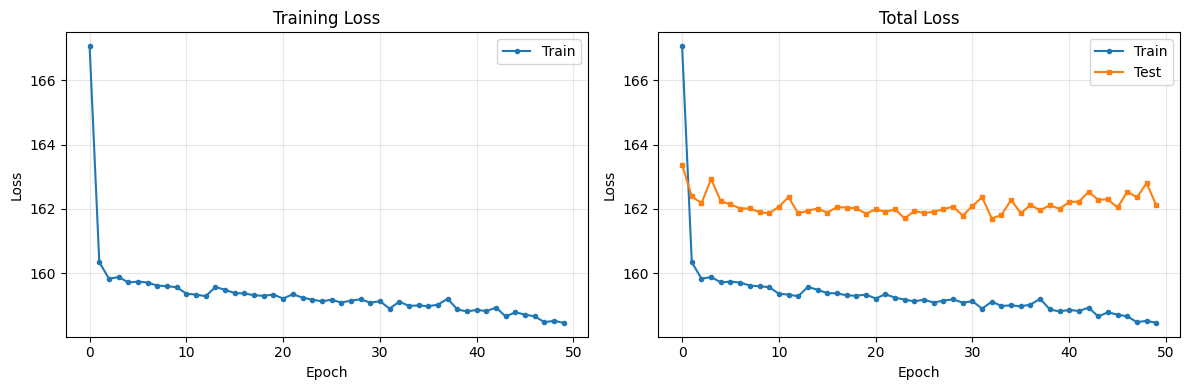

In [7]:
Visualizer.plot_training_history(
    history,
    save_path=os.path.join(config.RESULTS_DIR, 'easy_training_history.png')
)
plt.show()


In [8]:
all_loader = DataLoader(dataset, batch_size=config.BATCH_SIZE, shuffle=False)

latent_features, track_ids = extract_latent_features(
    trained_vae,
    all_loader,
    device=device
)

print(f"✓ Latent features: {latent_features.shape}")


✓ Latent features: (200, 20)


In [9]:
pipeline = ClusteringPipeline(n_clusters=10)

# VAE clustering
vae_labels, _ = pipeline.cluster_kmeans(latent_features)

# Baseline
original_features = np.vstack([f.numpy() for f, _ in all_loader])
baseline_labels, pca_features, _ = pipeline.baseline_pca_kmeans(original_features)

print(f"✓ Clustering done")


INFO:src.clustering:K-Means: [0 1 2 3 4 5 6 7 8 9]
INFO:src.clustering:PCA variance: 0.1530


✓ Clustering done


In [10]:
evaluator = MetricsEvaluator()

vae_metrics = evaluator.evaluate_all(latent_features, vae_labels)
baseline_metrics = evaluator.evaluate_all(pca_features, baseline_labels)

print("\nVAE Metrics:")
for metric, value in vae_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nBaseline Metrics:")
for metric, value in baseline_metrics.items():
    print(f"  {metric}: {value:.4f}")



VAE Metrics:
  Silhouette Score: 0.0493
  Calinski-Harabasz Index: 9.2039
  Davies-Bouldin Index: 2.4470

Baseline Metrics:
  Silhouette Score: 0.0918
  Calinski-Harabasz Index: 11.8972
  Davies-Bouldin Index: 1.9637


Computing t-SNE (this may take a minute)...
✓ Saved: E:\vae-music-clustering\results\latent_visualization\easy_tsne.png


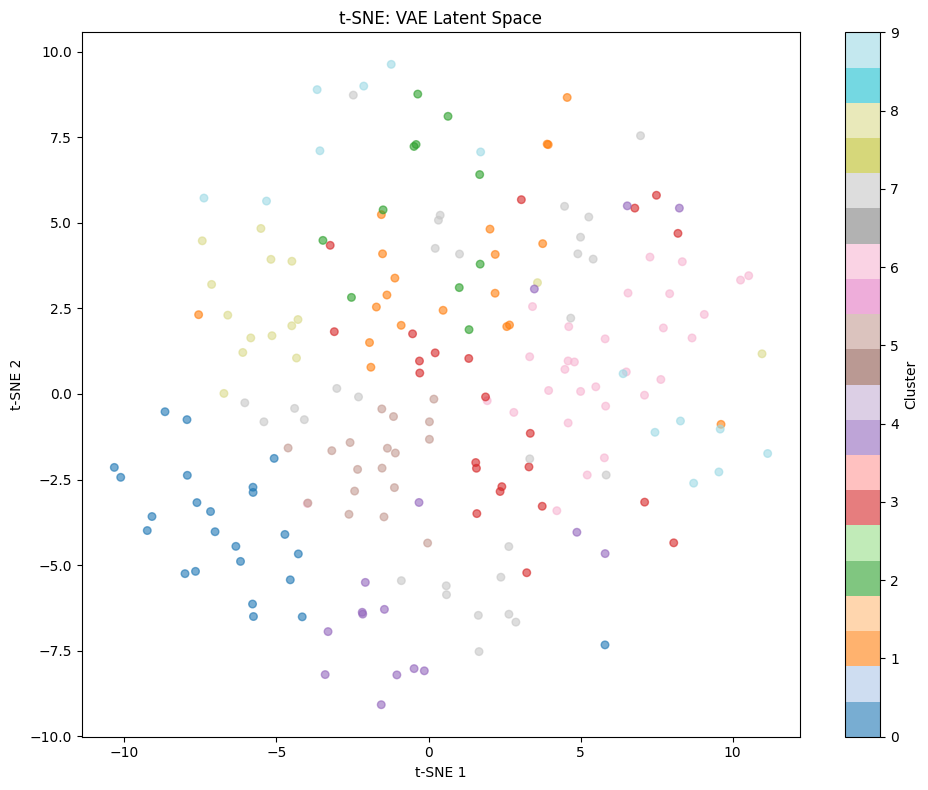

In [11]:
Visualizer.plot_tsne(
    latent_features,
    vae_labels,
    "t-SNE: VAE Latent Space",
    save_path=os.path.join(config.RESULTS_DIR, 'latent_visualization', 'easy_tsne.png')
)
plt.show()
